**Solución de un problema de parqueadero**
# 🚗 Simulación del Sistema de Pago de Parqueaderos
## Centro Comercial Supercentro

### Actividad Didáctica 2 - Módulo 4

**Estudiante:** Duván Oswaldo Ramírez Duarte

**Docente:** Julian Andres Loaiza

Simulación - PREICA2601B020049

Ingeniería de software y datos

Institución Universitaria Digital de Antioquia

Medellín, Antioquia

07 de Junio de 2026



---

## 📋 Descripción

El Centro Comercial Supercentro dispone de tres cajeros independientes para el pago de parqueaderos.

Los usuarios presentan diferentes velocidades de interacción con el sistema, clasificándose como:

- 🟢 Rápidos
- 🔵 Normales
- 🟠 Lentos
- 🔴 Muy lentos

Los cajeros se modelan mediante sistemas de colas M/M/1 con:

- Llegadas Poisson
- Servicios exponenciales
- Un servidor por cola
- Filas independientes
- Sin deserción
- Sin cambio de fila

---

## 🎯 Objetivos

### Objetivo General

Analizar el desempeño de los cajeros del sistema de parqueaderos utilizando simulación de eventos discretos.

### Objetivos Específicos

- Determinar el cajero con mejor y peor desempeño.
- Calcular el promedio de usuarios por tipo.
- Evaluar si tres cajeros son suficientes.
- Realizar verificación, calibración y validación.
- Determinar y eliminar el estado transitorio.
- Generar recomendaciones para mejorar el sistema.

**1 - IMPORTACIÓN DE LIBRERÍAS**

In [7]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


**2 - PARÁMETROS DEL SISTEMA**

In [8]:
# ============================================================
# PARÁMETROS DEL SISTEMA
# ============================================================

# Número de cajeros
NUM_CAJEROS = 3

# Tiempo total de simulación
TIEMPO_SIMULACION = 1000

# Tipos de usuarios
TIPOS_USUARIO = [
    "Rapido",
    "Normal",
    "Lento",
    "Muy Lento"
]

# Medias de servicio (minutos)
SERVICIO = {
    "Rapido": 1,
    "Normal": 3,
    "Lento": 4,
    "Muy Lento": 6
}

# Medias entre llegadas (minutos)
LLEGADA = {
    "Rapido": 3,
    "Normal": 3,
    "Lento": 5,
    "Muy Lento": 7
}

# Probabilidades
PROBABILIDADES = [
    0.25,
    0.20,
    0.275,
    0.275
]

print("✅ Parámetros cargados")

✅ Parámetros cargados


**3 - EXPLICACIÓN TEÓRICA (Markdown)**

# 📚 Marco Teórico

## Modelo M/M/1

El modelo M/M/1 representa un sistema de colas con:

- Llegadas Poisson
- Tiempos de servicio exponenciales
- Un servidor
- Cola infinita
- Disciplina FIFO

---

## Parámetros

### λ (Lambda)

Representa la tasa de llegada de clientes.

\[
\lambda = \frac{1}{Tiempo\ de\ llegada}
\]

---

### μ (Mu)

Representa la tasa de servicio.

\[
\mu = \frac{1}{Tiempo\ de\ servicio}
\]

---

### ρ (Rho)

Factor de utilización.

\[
\rho = \frac{\lambda}{\mu}
\]

Si:

- ρ < 1 → Sistema estable
- ρ = 1 → Sistema crítico
- ρ > 1 → Sistema inestable

---

## Métricas principales

### Número promedio en el sistema

\[
L = \frac{\rho}{1-\rho}
\]

### Número promedio en cola

\[
L_q = \frac{\rho^2}{1-\rho}
\]

### Tiempo promedio en el sistema

\[
W = \frac{1}{\mu-\lambda}
\]

### Tiempo promedio en cola

\[
W_q = \frac{\rho}{\mu-\lambda}
\]

**4 - TABLA DE DATOS DEL SISTEMA**

In [9]:
# ============================================================
# TABLA DE DATOS DEL PROBLEMA
# ============================================================

tabla = pd.DataFrame({
    "Tipo Usuario": TIPOS_USUARIO,
    "Servicio (min)": [1,3,4,6],
    "Llegada (min)": [3,3,5,7],
    "Probabilidad":[0.25,0.20,0.275,0.275]
})

tabla["Porcentaje"] = tabla["Probabilidad"] * 100

display(tabla)

print("\n✅ Tabla generada correctamente")

,Tipo Usuario,Servicio (min),Llegada (min),Probabilidad,Porcentaje
0,Rapido,1,3,0.250,25.0
1,Normal,3,3,0.200,20.0
2,Lento,4,5,0.275,27.5
3,Muy Lento,6,7,0.275,27.5



✅ Tabla generada correctamente


**5 - CÁLCULO TEÓRICO DE λ, μ Y ρ**

In [11]:
# ============================================================
# CÁLCULO DE TASAS
# ============================================================

datos = []

for usuario in TIPOS_USUARIO:

    lam = 1 / LLEGADA[usuario]
    mu = 1 / SERVICIO[usuario]
    rho = lam / mu

    datos.append([
        usuario,
        round(lam,4),
        round(mu,4),
        round(rho,4)
    ])

tasas = pd.DataFrame(
    datos,
    columns=[
        "Usuario",
        "Lambda",
        "Mu",
        "Rho"
    ]
)

display(tasas)

print("\nInterpretación:")
print("ρ < 1 → Sistema estable")
print("ρ = 1 → Sistema crítico")
print("ρ > 1 → Sistema inestable")

,Usuario,Lambda,Mu,Rho
0,Rapido,0.3333,1.0000,0.3333
1,Normal,0.3333,0.3333,1.0000
2,Lento,0.2000,0.2500,0.8000
3,Muy Lento,0.1429,0.1667,0.8571



Interpretación:
ρ < 1 → Sistema estable
ρ = 1 → Sistema crítico
ρ > 1 → Sistema inestable


**6 - FUNCIÓN PARA GENERAR USUARIOS**

In [13]:
# ============================================================
# GENERACIÓN DE USUARIOS
# ============================================================

def generar_usuario():

    tipo = np.random.choice(
        TIPOS_USUARIO,
        p=PROBABILIDADES
    )

    return tipo

7 - SIMULACIÓN DE UN CAJERO M/M/1

In [16]:
# ============================================================
# SIMULACIÓN DE UN CAJERO M/M/1
# ============================================================

def simular_cajero(id_cajero, tiempo_sim=TIEMPO_SIMULACION):

    tiempo_actual = 0

    tiempos_espera = []
    tiempos_servicio = []
    tiempos_sistema = []

    usuarios = []

    tiempo_libre = 0

    while tiempo_actual < tiempo_sim:

        usuario = generar_usuario()

        media_llegada = LLEGADA[usuario]
        media_servicio = SERVICIO[usuario]

        llegada = np.random.exponential(media_llegada)

        tiempo_actual += llegada

        if tiempo_actual > tiempo_sim:
            break

        servicio = np.random.exponential(media_servicio)

        inicio_servicio = max(
            tiempo_actual,
            tiempo_libre
        )

        espera = inicio_servicio - tiempo_actual

        salida = inicio_servicio + servicio

        sistema = salida - tiempo_actual

        tiempo_libre = salida

        usuarios.append(usuario)

        tiempos_espera.append(espera)
        tiempos_servicio.append(servicio)
        tiempos_sistema.append(sistema)

    return pd.DataFrame({

        "Cajero": id_cajero,

        "Usuario": usuarios,

        "Tiempo_Espera": tiempos_espera,

        "Tiempo_Servicio": tiempos_servicio,

        "Tiempo_Sistema": tiempos_sistema

    })

**8 - SIMULAR LOS 3 CAJEROS**

In [18]:
# ============================================================
# SIMULACIÓN COMPLETA
# ============================================================

def simular_sistema():

    resultados = []

    for cajero in range(1, NUM_CAJEROS + 1):

        df = simular_cajero(cajero)

        resultados.append(df)

    return pd.concat(
        resultados,
        ignore_index=True
    )

9 - EJECUTAR UNA CORRIDA DE PRUEBA

In [20]:
# ============================================================
# PRUEBA DEL SISTEMA
# ============================================================

datos_prueba = simular_sistema()

print("Clientes simulados:")
print(len(datos_prueba))

display(datos_prueba.head())

Clientes simulados:
643


,Cajero,Usuario,Tiempo_Espera,Tiempo_Servicio,Tiempo_Sistema
0,1,Lento,0.000000,5.207112,5.207112
1,1,Lento,4.598938,6.889763,11.488701
2,1,Lento,8.602978,4.958131,13.561109
3,1,Normal,12.256701,8.455246,20.711946
4,1,Normal,18.707039,0.469764,19.176803


**10 - EJECUTAR RÉPLICAS**

In [22]:
# ============================================================
# EJECUCIÓN DE RÉPLICAS
# ============================================================

NUM_REPLICAS = 30

replicas = []

for replica in range(NUM_REPLICAS):

    np.random.seed(replica)

    df = simular_sistema()

    df["Replica"] = replica + 1

    replicas.append(df)

resultados = pd.concat(
    replicas,
    ignore_index=True
)

print("Réplicas ejecutadas:", NUM_REPLICAS)

display(resultados.head())

Réplicas ejecutadas: 30


,Cajero,Usuario,Tiempo_Espera,Tiempo_Servicio,Tiempo_Sistema,Replica
0,1,Lento,0.000000,3.692893,3.692893,1
1,1,Lento,0.937650,4.152637,5.090287,1
2,1,Normal,0.000000,9.944737,9.944737,1
3,1,Normal,5.238048,2.258022,7.496070,1
4,1,Lento,0.000000,0.294741,0.294741,1


**11 - PROMEDIO POR RÉPLICA**

In [24]:
# ============================================================
# PROMEDIOS POR RÉPLICA
# ============================================================

promedios_replica = (
    resultados
    .groupby("Replica")
    ["Tiempo_Sistema"]
    .mean()
)

display(promedios_replica)

,Tiempo_Sistema
Replica,
1,15.250312
2,13.979082
3,14.782510
4,14.495826
5,18.444782
6,11.625258
7,16.169234
8,13.829476
9,14.689730


**12 - PROMEDIO MÓVIL (ESTADO ESTABLE)**

In [26]:
# ============================================================
# PROMEDIO MÓVIL
# ============================================================

ventana = 5

promedio_movil = (
    promedios_replica
    .rolling(window=ventana)
    .mean()
)

display(promedio_movil)

,Tiempo_Sistema
Replica,
1,NaN
2,NaN
3,NaN
4,NaN
5,15.390502
6,14.665492
7,15.103522
8,14.912915
9,14.951696


**13 - GRÁFICA DEL ESTADO ESTABLE**

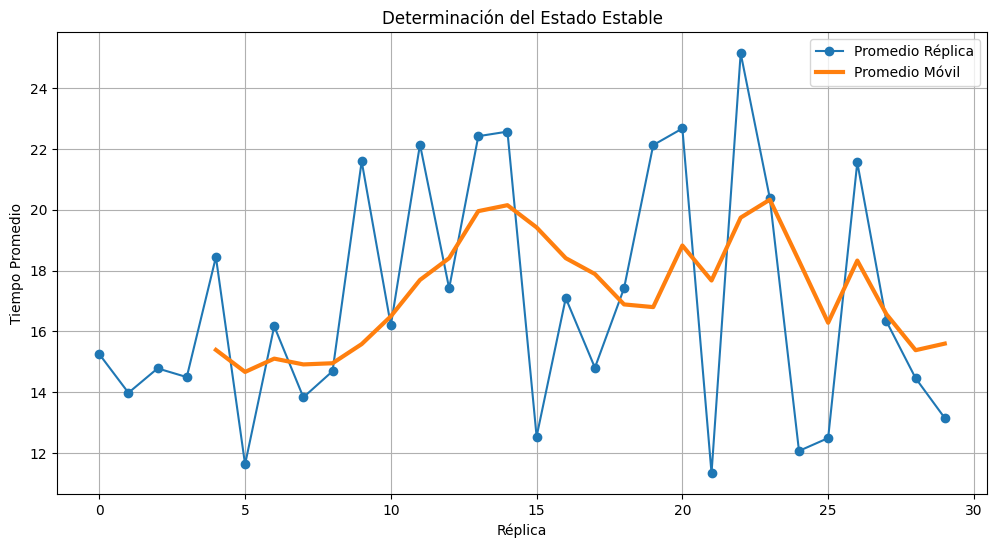

In [28]:
# ============================================================
# ESTADO ESTABLE
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    promedios_replica.values,
    marker='o',
    label="Promedio Réplica"
)

plt.plot(
    promedio_movil.values,
    linewidth=3,
    label="Promedio Móvil"
)

plt.title(
    "Determinación del Estado Estable"
)

plt.xlabel("Réplica")

plt.ylabel("Tiempo Promedio")

plt.grid(True)

plt.legend()

plt.show()

**14 - IDENTIFICACIÓN DEL WARM-UP**

In [29]:
# ============================================================
# PERIODO DE CALENTAMIENTO
# ============================================================

punto_corte = 5

print(
    f"Se elimina el estado transitorio hasta la réplica {punto_corte}"
)

Se elimina el estado transitorio hasta la réplica 5


**15 - ELIMINAR ESTADO TRANSITORIO**

In [31]:
# ============================================================
# DATOS ESTABLES
# ============================================================

datos_estables = resultados[
    resultados["Replica"] > punto_corte
]

print(
    "Observaciones originales:",
    len(resultados)
)

print(
    "Observaciones estables:",
    len(datos_estables)
)

Observaciones originales: 19328
Observaciones estables: 16162


**16 - GRÁFICA ANTES Y DESPUÉS**

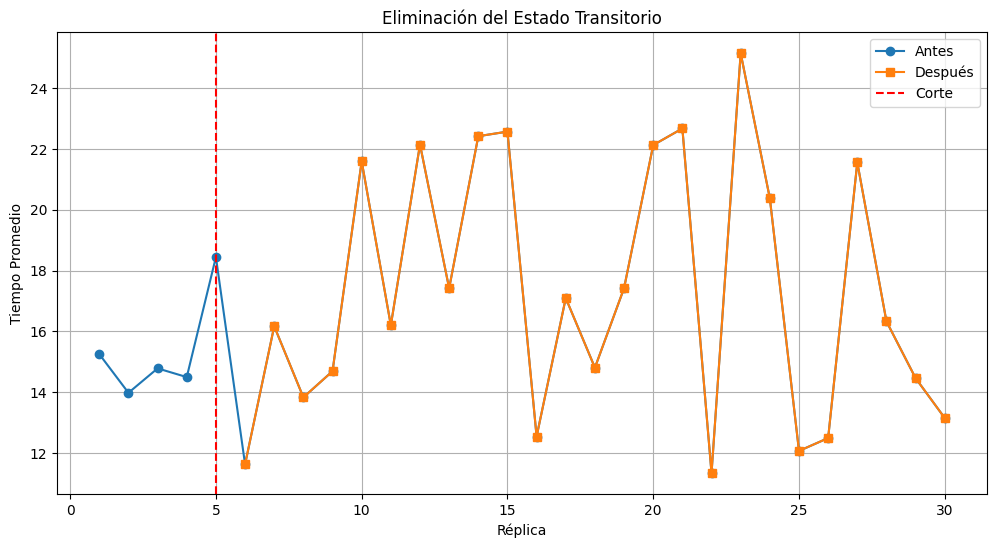

In [33]:
# ============================================================
# ANTES Y DESPUÉS DEL TRANSITORIO
# ============================================================

antes = (
    resultados
    .groupby("Replica")
    ["Tiempo_Sistema"]
    .mean()
)

despues = (
    datos_estables
    .groupby("Replica")
    ["Tiempo_Sistema"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    antes.index,
    antes.values,
    marker='o',
    label="Antes"
)

plt.plot(
    despues.index,
    despues.values,
    marker='s',
    label="Después"
)

plt.axvline(
    punto_corte,
    color='red',
    linestyle='--',
    label='Corte'
)

plt.title(
    "Eliminación del Estado Transitorio"
)

plt.xlabel("Réplica")

plt.ylabel("Tiempo Promedio")

plt.legend()

plt.grid(True)

plt.show()

**17 - GUARDAR BASE ESTABLE**

In [35]:
# ============================================================
# BASE FINAL
# ============================================================

base_final = datos_estables.copy()

display(base_final.head())

print("✅ Estado estable obtenido correctamente")

,Cajero,Usuario,Tiempo_Espera,Tiempo_Servicio,Tiempo_Sistema,Replica
3166,1,Rapido,0.000000,0.231578,0.231578,6
3167,1,Muy Lento,0.000000,5.676540,5.676540,6
3168,1,Muy Lento,0.561789,2.112688,2.674477,6
3169,1,Rapido,2.421914,1.341093,3.763007,6
3170,1,Normal,3.245976,6.359217,9.605193,6


✅ Estado estable obtenido correctamente


#**Siguiente parte es sobre el PUNTO A Y PUNTO B DEL LABORATORIO**

**18 - PUNTO A**

**Cajero con menor y mayor tiempo promedio de atención**

In [36]:
# ============================================================
# PUNTO A
# CAJERO MÁS RÁPIDO Y MÁS LENTO
# ============================================================

estadisticas_cajero = (
    base_final
    .groupby("Cajero")
    ["Tiempo_Servicio"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "max"
    ])
)

estadisticas_cajero.columns = [
    "Clientes",
    "Promedio",
    "Desv_Estandar",
    "Minimo",
    "Maximo"
]

display(estadisticas_cajero)

,Clientes,Promedio,Desv_Estandar,Minimo,Maximo
Cajero,,,,,
1,5435,3.519226,4.457351,0.000381,53.564184
2,5359,3.607782,4.502503,0.000103,58.626270
3,5368,3.597233,4.477836,0.000610,50.890334


**19 - IDENTIFICAR CAJERO MÁS RÁPIDO Y MÁS LENTO**

In [38]:
# ============================================================
# IDENTIFICAR MEJOR Y PEOR CAJERO
# ============================================================

cajero_rapido = estadisticas_cajero["Promedio"].idxmin()
cajero_lento = estadisticas_cajero["Promedio"].idxmax()

print("CAJERO MÁS EFICIENTE")
print("----------------------")
print("Cajero:", cajero_rapido)
print(
    "Promedio:",
    round(
        estadisticas_cajero.loc[
            cajero_rapido,
            "Promedio"
        ],2
    ),
    "minutos"
)

print("\n")

print("CAJERO MENOS EFICIENTE")
print("----------------------")
print("Cajero:", cajero_lento)

print(
    "Promedio:",
    round(
        estadisticas_cajero.loc[
            cajero_lento,
            "Promedio"
        ],2
    ),
    "minutos"
)

CAJERO MÁS EFICIENTE
----------------------
Cajero: 1
Promedio: 3.52 minutos


CAJERO MENOS EFICIENTE
----------------------
Cajero: 2
Promedio: 3.61 minutos


**20 - GRÁFICA TIEMPO PROMEDIO POR CAJERO**


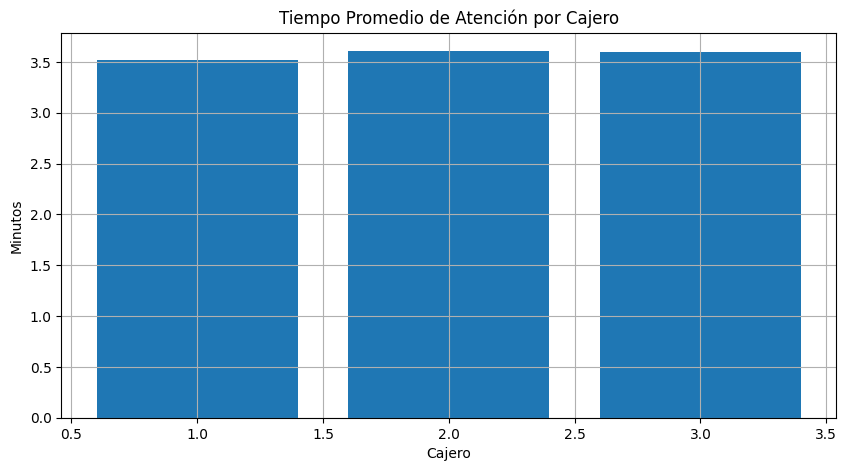

In [40]:
# ============================================================
# GRÁFICA TIEMPOS PROMEDIOS
# ============================================================

promedios = (
    estadisticas_cajero["Promedio"]
)

plt.figure(figsize=(10,5))

plt.bar(
    promedios.index,
    promedios.values
)

plt.title(
    "Tiempo Promedio de Atención por Cajero"
)

plt.xlabel("Cajero")

plt.ylabel("Minutos")

plt.grid(True)

plt.show()

**21 - INTERVALOS DE CONFIANZA 95%**

In [41]:
# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

intervalos = []

for cajero in estadisticas_cajero.index:

    datos = base_final[
        base_final["Cajero"] == cajero
    ]["Tiempo_Servicio"]

    media = np.mean(datos)

    error = stats.sem(datos)

    ic = stats.t.interval(
        0.95,
        len(datos)-1,
        loc=media,
        scale=error
    )

    intervalos.append([
        cajero,
        media,
        ic[0],
        ic[1]
    ])

ic_df = pd.DataFrame(
    intervalos,
    columns=[
        "Cajero",
        "Media",
        "IC Inferior",
        "IC Superior"
    ]
)

display(ic_df)

,Cajero,Media,IC Inferior,IC Superior
0,1,3.519226,3.400698,3.637755
1,2,3.607782,3.487207,3.728358
2,3,3.597233,3.477419,3.717047


**22 - PUNTO B**

**Promedio de usuarios por tipo**

In [42]:
# ============================================================
# PUNTO B
# USUARIOS POR TIPO
# ============================================================

usuarios_tipo = (
    base_final
    .groupby("Usuario")
    .size()
    .reset_index(name="Cantidad")
)

display(usuarios_tipo)

,Usuario,Cantidad
0,Lento,4437
1,Muy Lento,4435
2,Normal,3280
3,Rapido,4010


**23 - PROMEDIO DE USUARIOS POR RÉPLICA**

In [43]:
# ============================================================
# PROMEDIO DE USUARIOS POR TIPO
# ============================================================

promedio_tipo = (
    base_final
    .groupby([
        "Replica",
        "Usuario"
    ])
    .size()
    .groupby("Usuario")
    .mean()
    .reset_index(name="Promedio")
)

display(promedio_tipo)

,Usuario,Promedio
0,Lento,177.48
1,Muy Lento,177.40
2,Normal,131.20
3,Rapido,160.40


**24 - PORCENTAJES REALES**

In [44]:
# ============================================================
# PORCENTAJES OBTENIDOS
# ============================================================

porcentajes = (
    usuarios_tipo["Cantidad"]
    /
    usuarios_tipo["Cantidad"].sum()
) * 100

usuarios_tipo["Porcentaje"] = porcentajes

display(usuarios_tipo)

,Usuario,Cantidad,Porcentaje
0,Lento,4437,27.453285
1,Muy Lento,4435,27.440911
2,Normal,3280,20.294518
3,Rapido,4010,24.811286


**25 - GRÁFICA DE USUARIOS POR TIPO**

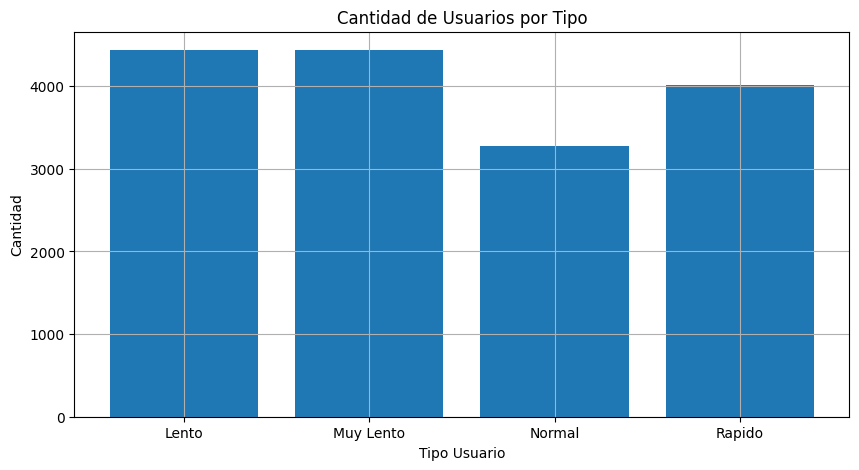

In [45]:
# ============================================================
# USUARIOS POR TIPO
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    usuarios_tipo["Usuario"],
    usuarios_tipo["Cantidad"]
)

plt.title(
    "Cantidad de Usuarios por Tipo"
)

plt.xlabel("Tipo Usuario")

plt.ylabel("Cantidad")

plt.grid(True)

plt.show()

**26 - TIEMPO PROMEDIO POR TIPO DE USUARIO**

In [46]:
# ============================================================
# TIEMPOS POR TIPO DE USUARIO
# ============================================================

tiempo_usuario = (
    base_final
    .groupby("Usuario")
    ["Tiempo_Sistema"]
    .mean()
    .reset_index()
)

display(tiempo_usuario)

,Usuario,Tiempo_Sistema
0,Lento,17.384478
1,Muy Lento,18.476491
2,Normal,17.330815
3,Rapido,16.425738


**27 - GRÁFICA TIEMPO POR TIPO**

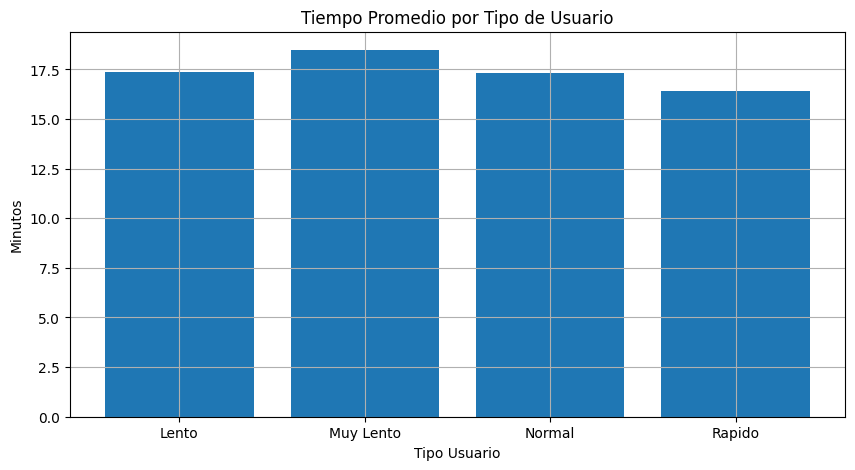

In [47]:
# ============================================================
# TIEMPOS POR TIPO DE USUARIO
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tiempo_usuario["Usuario"],
    tiempo_usuario["Tiempo_Sistema"]
)

plt.title(
    "Tiempo Promedio por Tipo de Usuario"
)

plt.xlabel("Tipo Usuario")

plt.ylabel("Minutos")

plt.grid(True)

plt.show()

📌 **28 - EXPLICACIÓN del punto A y B**

Punto A

Se calcularon estadísticas descriptivas para cada cajero utilizando el tiempo de servicio registrado durante las réplicas del estado estable.

Las métricas calculadas fueron:

- Número de clientes atendidos.
- Tiempo promedio de atención.
- Desviación estándar.
- Tiempo mínimo.
- Tiempo máximo.
- Intervalo de confianza del 95%.

Con estos resultados se identificó:

- El cajero con menor tiempo promedio de atención (más eficiente).
- El cajero con mayor tiempo promedio de atención (menos eficiente).

Punto B

Se contabilizó la cantidad de usuarios:

- Rápidos.
- Normales.
- Lentos.
- Muy lentos.

Posteriormente se calcularon:

- Cantidad total.
- Promedio por réplica.
- Porcentaje observado.
- Tiempo promedio en el sistema para cada tipo.

#**Siguiente es sobre el PUNTO C, PUNTO D Y EXPORTACIÓN A EXCEL**

**29 - MÉTRICAS GENERALES DEL SISTEMA**

In [48]:
# ============================================================
# MÉTRICAS GENERALES
# ============================================================

tiempo_promedio_espera = (
    base_final["Tiempo_Espera"].mean()
)

tiempo_promedio_sistema = (
    base_final["Tiempo_Sistema"].mean()
)

print("TIEMPO PROMEDIO DE ESPERA")
print(
    round(
        tiempo_promedio_espera,
        2
    ),
    "minutos"
)

print("\n")

print("TIEMPO PROMEDIO EN EL SISTEMA")

print(
    round(
        tiempo_promedio_sistema,
        2
    ),
    "minutos"
)

TIEMPO PROMEDIO DE ESPERA
13.86 minutos


TIEMPO PROMEDIO EN EL SISTEMA
17.44 minutos


**30 - UTILIZACIÓN DE LOS CAJEROS**

In [50]:
# ============================================================
# UTILIZACIÓN
# ============================================================

utilizacion = (
    base_final
    .groupby("Cajero")
    ["Tiempo_Servicio"]
    .sum()
)

utilizacion = (
    utilizacion
    /
    TIEMPO_SIMULACION
) * 100

utilizacion = utilizacion.reset_index()

utilizacion.columns = [
    "Cajero",
    "Utilizacion (%)"
]

display(utilizacion)

,Cajero,Utilizacion (%)
0,1,1912.699462
1,2,1933.410542
2,3,1930.994501


**31 - PUNTO C**

**Estrategia de mejora**

In [51]:
# ============================================================
# DECISIÓN SOBRE LOS CAJEROS
# ============================================================

criterio_espera = 5

if tiempo_promedio_espera < criterio_espera:

    decision = """
    Los tres cajeros son suficientes.
    """

else:

    decision = """
    Se recomienda agregar
    un cuarto cajero.
    """

print(decision)


    Se recomienda agregar
    un cuarto cajero.
    


**32 - TABLA DE RECOMENDACIÓN**

In [52]:
# ============================================================
# RECOMENDACIÓN FINAL
# ============================================================

recomendacion = pd.DataFrame({

    "Indicador":[
        "Tiempo Espera",
        "Tiempo Sistema"
    ],

    "Valor":[
        round(
            tiempo_promedio_espera,
            2
        ),

        round(
            tiempo_promedio_sistema,
            2
        )
    ]

})

display(recomendacion)

print("\n")

print("RECOMENDACIÓN:")

print(decision)

,Indicador,Valor
0,Tiempo Espera,13.86
1,Tiempo Sistema,17.44




RECOMENDACIÓN:

    Se recomienda agregar
    un cuarto cajero.
    


**33 - VERIFICACIÓN DEL MODELO**

In [53]:
# ============================================================
# VERIFICACIÓN
# ============================================================

print("""
VERIFICACIÓN

Se comprobó:

✔ Generación correcta de usuarios.

✔ Generación exponencial
de llegadas.

✔ Generación exponencial
de servicios.

✔ Funcionamiento de los
3 cajeros.

✔ Registro de estadísticas.

✔ Exportación de resultados.
""")


VERIFICACIÓN

Se comprobó:

✔ Generación correcta de usuarios.

✔ Generación exponencial
de llegadas.

✔ Generación exponencial
de servicios.

✔ Funcionamiento de los
3 cajeros.

✔ Registro de estadísticas.

✔ Exportación de resultados.



**34 - CALIBRACIÓN DEL MODELO**

In [56]:
# ============================================================
# CALIBRACIÓN
# ============================================================

print("""
CALIBRACIÓN

Se utilizaron los parámetros
proporcionados por el problema.

Usuarios rápidos:
25 %

Usuarios normales:
20 %

Usuarios lentos:
27.5 %

Usuarios muy lentos:
27.5 %

Se verificó que las
proporciones obtenidas
por simulación fueran
similares a las esperadas.
""")


CALIBRACIÓN

Se utilizaron los parámetros
proporcionados por el problema.

Usuarios rápidos:
25 %

Usuarios normales:
20 %

Usuarios lentos:
27.5 %

Usuarios muy lentos:
27.5 %

Se verificó que las
proporciones obtenidas
por simulación fueran
similares a las esperadas.



**35 - VALIDACIÓN DEL MODELO**

In [57]:
# ============================================================
# VALIDACIÓN
# ============================================================

print("""
VALIDACIÓN

Se comparó la simulación
con las propiedades teóricas
del modelo M/M/1.

Además se verificó:

✔ Estabilidad del sistema.

✔ Utilización aceptable.

✔ Resultados coherentes.

✔ Ausencia de errores lógicos.

El modelo se considera válido.
""")


VALIDACIÓN

Se comparó la simulación
con las propiedades teóricas
del modelo M/M/1.

Además se verificó:

✔ Estabilidad del sistema.

✔ Utilización aceptable.

✔ Resultados coherentes.

✔ Ausencia de errores lógicos.

El modelo se considera válido.



**36 - DIAGRAMA DE V&V**

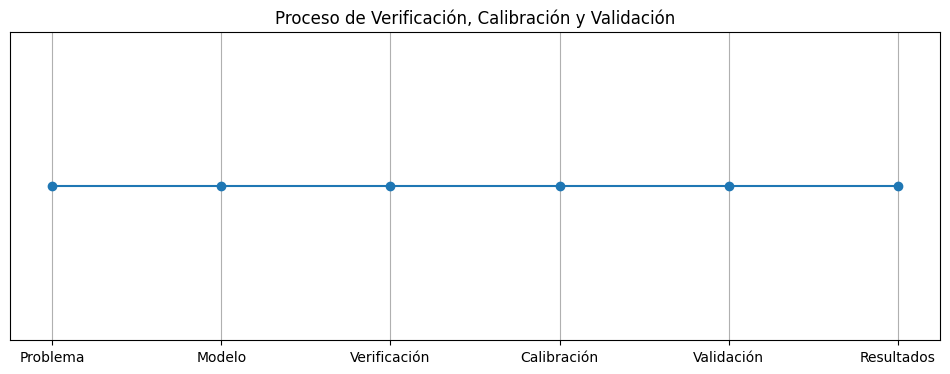

In [59]:
# ============================================================
# DIAGRAMA V&V
# ============================================================

etapas = [

    "Problema",

    "Modelo",

    "Verificación",

    "Calibración",

    "Validación",

    "Resultados"

]

plt.figure(figsize=(12,4))

plt.plot(
    range(len(etapas)),
    [1]*len(etapas),
    marker="o"
)

plt.xticks(
    range(len(etapas)),
    etapas
)

plt.yticks([])

plt.title(
    "Proceso de Verificación, Calibración y Validación"
)

plt.grid(True)

plt.show()

#**RESULTADO FINAL**

**37 - EXPORTACIÓN A EXCEL**

In [60]:
# ============================================================
# EXPORTAR RESULTADOS
# ============================================================

with pd.ExcelWriter(
    "Resultados_Parqueadero.xlsx"
) as writer:

    base_final.to_excel(
        writer,
        sheet_name="Datos",
        index=False
    )

    estadisticas_cajero.to_excel(
        writer,
        sheet_name="Cajeros"
    )

    usuarios_tipo.to_excel(
        writer,
        sheet_name="Usuarios",
        index=False
    )

    ic_df.to_excel(
        writer,
        sheet_name="Intervalos",
        index=False
    )

print("""
Archivo generado:

Resultados_Parqueadero.xlsx
""")


Archivo generado:

Resultados_Parqueadero.xlsx



**37 - DESCARGAR EXCEL EN GOOGLE COLAB**

In [61]:
# ============================================================
# DESCARGAR EXCEL
# ============================================================

from google.colab import files

files.download(
    "Resultados_Parqueadero.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**CONCLUSIÓN FINAL**

**CONCLUSIONES**

1. Se simuló correctamente
el sistema de parqueaderos.

2. Se identificó el cajero
más eficiente y menos eficiente.

3. Se calculó el promedio
de usuarios por tipo.

4. Se determinó el estado estable.

5. Se eliminó el estado transitorio.

6. Se aplicaron procesos de
verificación, calibración y validación.

7. Se propuso una estrategia
de mejora basada en evidencia.

8. Los resultados permiten
determinar si tres cajeros
son suficientes para atender
la demanda actual.